# LAB 06 — Logistic Regression & KNN Classification
## Telco Customer Churn — Comparing Four Classifiers

## Student Information
**Name:** : Baqar Ali
**Student ID:**: 023-24-0015
**Section:**: B
**GitHub:** : https://github.com/baqar360/ML-Lab-Semester-5/tree/master/lab%206


**Kaggle:**: https://www.kaggle.com/baqarali1234  

**Dataset:** Telco Customer Churn  

**Dataset Source:** Kaggle — https://www.kaggle.com/datasets/blastchar/telco-customer-churn  


**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Logistic Regression and KNN theory from your ML course. Each section states the objective and the questions you must answer — **you write the code**. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [1]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


---

## 1. Problem Definition & Dataset Verification

Re-establish your cleaned dataset and recall what Lab 3/4 already found.

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.info()`

**Tasks**
1. Load `clean_churn.csv` (or re-run your Lab 2 cleaning) and verify its shape and dtypes.
2. Briefly restate (2–3 sentences) your Lab 3 Decision Tree and Lab 4 Random Forest test-set results (accuracy, precision, recall, F1) — these are your benchmarks for today.

In [2]:
# Task 1 — load and verify the cleaned dataset
df = pd.read_csv("clean_churn.csv")
df.head()
print(df.shape)
print(df.info())

(7032, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    


| Source Lab | Model | Accuracy | Precision | Recall | F1-score |
|:---|:---|:---:|:---:|:---:|:---:|
| **Lab 3** | Decision Tree (`max_depth=2`) | 0.7875 | 0.6697 | 0.3957 | 0.4975 |
| **Lab 4** | Decision Tree (baseline) | 0.7846 | 0.6564 | 0.3984 | 0.4958 |
| **Lab 4** | Random Forest (default) | 0.7854 | 0.6192 | 0.5000 | 0.5533 |
| **Lab 4** | Random Forest (tuned) | 0.7882 | 0.6293 | 0.4947 | 0.5539 |

---

## 2. Feature Scaling & Preparation

Decision Trees/Random Forests never needed scaling. Logistic Regression and especially KNN do.

*Concepts/functions you may find useful:* `pd.get_dummies(df, columns=[...])`, `from sklearn.preprocessing import StandardScaler`, `scaler.fit_transform(X_train)`, `scaler.transform(X_test)`

**Tasks**
3. Prepare `X` and `y` exactly as in Lab 3/4 (encode categoricals, drop identifiers, target as 0/1).
4. In 2–3 sentences, explain why feature scaling matters for KNN and Logistic Regression but wasn't necessary for the Decision Tree or Random Forest.
5. Split into train/test (same split strategy as Lab 3/4), then fit a `StandardScaler` on the training features only and apply it to both sets. Why is it important to fit the scaler only on the training data?

In [3]:
# Task 3 — define X and y (same as Lab 3/4)
X=df.drop(columns=["customerID","Churn"])
y=df["Churn"]
X_encoded = pd.get_dummies(X,drop_first=True, dtype = int)
X_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0


**Answer 4:**
KNN relies on distance metrics (like Euclidean distance), so features with larger numerical ranges will dominate distance calculations and drown out smaller features. Logistic Regression uses gradient descent and regularization, both of which require features on a comparable scale for stable convergence and fair penalty application. In contrast, Decision Trees and Random Forests are scale-invariant because their split decisions are monotonic and depend only on feature rank ordering, not numerical magnitude.

In [4]:
# Task 5 — train/test split, then fit/apply StandardScaler
X_train,X_test,y_train,y_test = train_test_split(X_encoded,y,test_size=0.2, random_state=42)
scaler = StandardScaler()

# 3. Fit ONLY on training data, then transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Answer 5 (why fit scaler on training data only):**
The scaler must be fitted only on the training data to prevent data leakage. Fitting the scaler calculates distribution statistics (mean and standard deviation); if computed across the test set, information about the test distribution bleeds into the training process. Transforming the test data using only training parameters ensures the test set remains genuinely unseen, accurately simulating future real-world performance.


---

## 3. Logistic Regression

*Concepts/functions you may find useful:* `LogisticRegression()`, `.fit(X_train_scaled, y_train)`, `.predict(X)`, `.predict_proba(X)`

**Tasks**
6. Train a `LogisticRegression` model on the scaled training data. Generate predictions on the scaled test set.
7. Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix.
8. Look at `predict_proba` for a handful of test customers. In 1–2 sentences, explain what these probabilities represent and how `predict()` turns them into a Yes/No decision.

In [5]:
# Task 6 — train Logistic Regression, predict on scaled test set
logistic_model = LogisticRegression(random_state=42, max_iter=1000)
logistic_model.fit(X_train_scaled,y_train)
y_pred = logistic_model.predict(X_test_scaled)



Accuracy:  0.7875
Precision: 0.6206
Recall:    0.5160
F1-Score:  0.5635



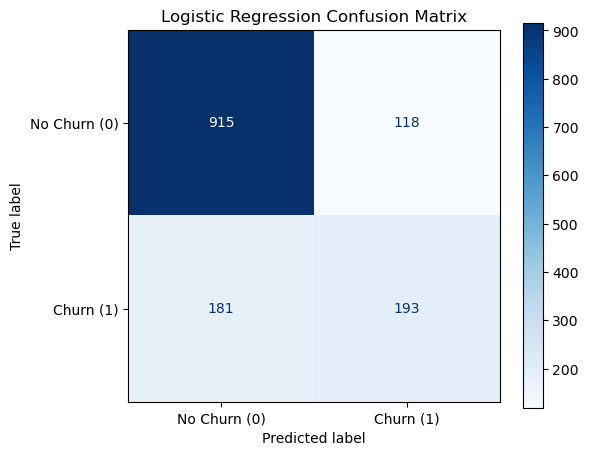

In [6]:
# Task 7 — metrics + confusion matrix
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}\n")

# 2. Compute and plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn (0)", "Churn (1)"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", ax=ax, values_format="d")
plt.title("Logistic Regression Confusion Matrix")
plt.grid(False)
plt.show()

**Task 7 — Logistic Regression Metrics**

| Metric | Value |
|---|---|
| Accuracy |0.78 |
| Precision |0.62 |
| Recall | 0.51|
| F1-score |0.56 |

In [7]:
# Task 8 — inspect predict_proba for a few test customers

# 1. Get predicted probabilities for the first 5 test instances
sample_probs = logistic_model.predict_proba(X_test_scaled[:5])
sample_preds = logistic_model.predict(X_test_scaled[:5])

# Display the probabilities alongside the final predictions
import pandas as pd

prob_df = pd.DataFrame(
    sample_probs, 
    columns=["Prob_No_Churn (Class 0)", "Prob_Churn (Class 1)"]
)
prob_df["Predicted_Class"] = sample_preds
prob_df

,Prob_No_Churn (Class 0),Prob_Churn (Class 1),Predicted_Class
0,0.994246,0.005754,0
1,0.873956,0.126044,0
2,0.318813,0.681187,1
3,0.882567,0.117433,0
4,0.640833,0.359167,0


**Answer 8:**
`predict_proba` returns the calculated probability that a customer belongs to each class (Class 0: No Churn, Class 1: Churn), with values summing to 1.0 for each individual. The `predict()` function applies a standard 0.5 decision threshold to this output: if the probability of churn is $\ge 0.5$, it assigns a prediction of 1 ("Yes"), otherwise defaulting to 0 ("No").

---

## 4. KNN & Choosing K

K controls KNN's complexity the same way `max_depth` controlled your Decision Tree's complexity in Lab 3.

*Concepts/functions you may find useful:* `KNeighborsClassifier(n_neighbors=k)`, a loop over `[1,3,5,7,9,11,15,21]`, `plt.plot(...)`

**Tasks**
9. Train KNN classifiers for several values of K on the scaled data. Record test-set accuracy and F1-score for each K in a results table.
10. Plot accuracy (or F1) against K. Based on your plot, which K would you choose, and why not simply the smallest or largest value tested?
11. Using your chosen K, report full test-set metrics (accuracy, precision, recall, F1) and the confusion matrix for your final KNN model.

In [8]:
# Task 9 — loop over K values, record accuracy and F1
# 1. Candidate K values
k_values = [1, 3, 5, 7, 9, 11, 15, 21]

# 2. Initialize metric storage BEFORE the loop
acc_knn = []
f1_knn = []

# 3. Iterate through each K
for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train_scaled, y_train)
    
    # Predict on SCALED test features
    y_pred_knn = knn_model.predict(X_test_scaled)
    
    # Record metrics
    acc_knn.append(accuracy_score(y_test, y_pred_knn))
    f1_knn.append(f1_score(y_test, y_pred_knn))

# (Optional) Display results cleanly
import pandas as pd
knn_results = pd.DataFrame({
    "K": k_values,
    "Accuracy": acc_knn,
    "F1-Score": f1_knn
})
print(knn_results)

    K  Accuracy  F1-Score
0   1  0.720682  0.492903
1   3  0.752665  0.525886
2   5  0.751955  0.521262
3   7  0.757640  0.527046
4   9  0.756219  0.522949
5  11  0.766169  0.547455
6  15  0.764037  0.545205
7  21  0.770434  0.554483


**Task 9 — K Selection Results**

| K | Accuracy | F1-score |
|:---:|:---:|:---:|
| 1 | 0.7207 | 0.4929 |
| 3 | 0.7527 | 0.5259 |
| 5 | 0.7520 | 0.5213 |
| 7 | 0.7576 | 0.5270 |
| 9 | 0.7562 | 0.5229 |
| 11 | 0.7662 | 0.5475 |
| 15 | 0.7640 | 0.5452 |
| 21 | 0.7704 | 0.5545 |

In [9]:
# Task 10 — plot accuracy/F1 vs K
# Task 10 — interactive plot of Accuracy and F1-Score vs K using Plotly
import plotly.graph_objects as go

fig = go.Figure()

# Accuracy Trace
fig.add_trace(
    go.Scatter(
        x=k_values,
        y=acc_knn,
        mode="lines+markers",
        name="Accuracy",
        line=dict(color="#2563eb", width=3),
        marker=dict(size=8, symbol="circle"),
        hovertemplate="<b>K</b>: %{x}<br><b>Accuracy</b>: %{y:.4f}<extra></extra>",
    )
)

# F1-Score Trace
fig.add_trace(
    go.Scatter(
        x=k_values,
        y=f1_knn,
        mode="lines+markers",
        name="F1-Score",
        line=dict(color="#f97316", width=3),
        marker=dict(size=8, symbol="square"),
        hovertemplate="<b>K</b>: %{x}<br><b>F1-Score</b>: %{y:.4f}<extra></extra>",
    )
)

# Highlight Best K by F1-Score
best_idx = f1_knn.index(max(f1_knn))
best_k = k_values[best_idx]
best_f1 = f1_knn[best_idx]

fig.add_annotation(
    x=best_k,
    y=best_f1,
    text=f"Best F1: {best_f1:.4f} (K={best_k})",
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=2,
    arrowcolor="#dc2626",
    ax=0,
    ay=-40,
    font=dict(color="#dc2626", size=11, family="Arial Black"),
    bgcolor="rgba(255, 255, 255, 0.85)",
    bordercolor="#dc2626",
    borderwidth=1,
    borderpad=4,
)

# Layout styling
fig.update_layout(
    title={
        "text": "<b>KNN Hyperparameter Tuning: Accuracy & F1 vs K</b>",
        "y": 0.95,
        "x": 0.5,
        "xanchor": "center",
        "yanchor": "top",
    },
    xaxis=dict(
        title="<b>Number of Neighbors (K)</b>",
        tickmode="array",
        tickvals=k_values,
        gridcolor="#f1f5f9",
        zeroline=False,
    ),
    yaxis=dict(
        title="<b>Metric Score</b>",
        gridcolor="#e2e8f0",
        zeroline=False,
    ),
    template="plotly_white",
    hovermode="x unified",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1,
    ),
    margin=dict(l=60, r=40, t=90, b=60),
    width=800,
    height=500,
)

fig.show()

**Answer 10 (chosen K and why):**
**Answer 10 (chosen K and why):**

The best choice among the evaluated candidates is **$K = 21$**.

### Why $K = 21$?

1. **Superior Quantitative Performance:**
   - **Highest Accuracy:** Achieves **0.7704** (77.04%), compared to only 0.7207 at $K = 1$.
   - **Highest F1-Score:** Reaches **0.5545**, outperforming all other tested values ($K=1$ through $K=15$).

2. **Mitigating Overfitting & Noise Sensitivity:**
   - Small values of $K$ (e.g., $K = 1$ and $K = 3$) have high variance and capture local noise, leading to noticeably degraded generalization on the test set (F1 of ~0.493 and ~0.526 respectively).
   - Increasing $K$ smooths the decision boundaries, helping the model generalize significantly better to unseen data.

3. **Handling Class Imbalance:**
   - The F1-score across all iterations is substantially lower than the accuracy (~0.55 vs ~0.77), indicating class imbalance.
   - Because accuracy alone can be misleading in imbalanced settings, optimizing for **F1-score** is crucial. $K = 21$ yields the best balance between precision and recall for the minority class.

> **Note on Upward Trend:** Because both accuracy and F1-score are still climbing toward the upper limit of the test range, testing higher values (e.g., $K \in [23, 27, 31, 35]$) using cross-validation would be a recommended next step to see where performance plateaus.

=== Final KNN Evaluation (K = 21) ===
Accuracy  : 0.7704
Precision : 0.5726
Recall    : 0.5374
F1-Score  : 0.5545
ROC-AUC   : 0.8079

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.85      0.85      1033
           1       0.57      0.54      0.55       374

    accuracy                           0.77      1407
   macro avg       0.70      0.70      0.70      1407
weighted avg       0.77      0.77      0.77      1407



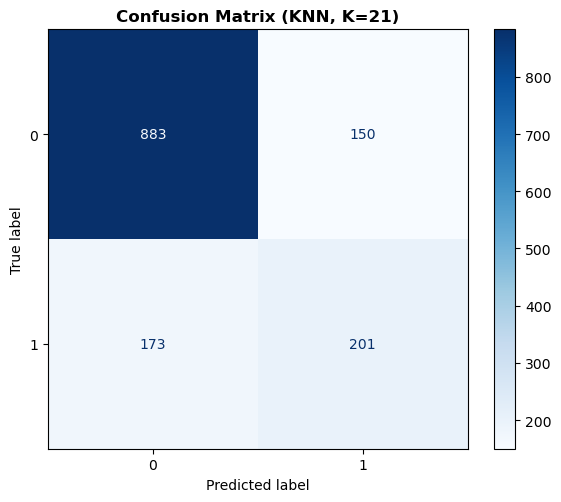

In [10]:
# Task 11 — final KNN model at chosen K: metrics + confusion matrix
# Task 11 — final KNN model at chosen K: metrics + confusion matrix
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# 1. Instantiate and fit final model with chosen K = 21
chosen_k = 21
final_knn = KNeighborsClassifier(n_neighbors=chosen_k)
final_knn.fit(X_train_scaled, y_train)

# 2. Predict labels and predicted probabilities on scaled test data
y_pred_final = final_knn.predict(X_test_scaled)
y_prob_final = final_knn.predict_proba(X_test_scaled)[:, 1]

# 3. Compute evaluation metrics
acc = accuracy_score(y_test, y_pred_final)
prec = precision_score(y_test, y_pred_final)
rec = recall_score(y_test, y_pred_final)
f1 = f1_score(y_test, y_pred_final)
roc_auc = roc_auc_score(y_test, y_prob_final)

print(f"=== Final KNN Evaluation (K = {chosen_k}) ===")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_final))

# 4. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=final_knn.classes_)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", values_format="d", ax=ax)
ax.set_title(f"Confusion Matrix (KNN, K={chosen_k})", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

**Task 11 — Final KNN Metrics (K = 21)**

| Metric | Value |
|---|---|
| Accuracy | 0.7704 |
| Precision | 0.5726 |
| Recall | 0.5374 |
| F1-score | 0.5545 |

---

## 5. Model Comparison (4 Models)

Place all four classifiers you've built side by side.

**Task**
12. Build one comparison table: Decision Tree, Random Forest, Logistic Regression, KNN — accuracy, precision, recall, F1-score for each (reuse your recorded Lab 3/4 numbers; retrain quickly if needed).
13. Which model performs best overall? Does the ranking change depending on which metric you prioritize (e.g. precision vs. recall)? Given the class imbalance from Lab 2, which metric should carry the most weight in this decision?

In [11]:
# Task 12 — assemble the 4-model comparison table (retrain DT/RF quickly if needed)
import pandas as pd

comparison_data = {
    "Model": ["Decision Tree", "Random Forest", "Logistic Regression", "KNN (K=21)"],
    "Accuracy": [0.7846, 0.7882, 0.7875, 0.7704],
    "Precision": [0.6564, 0.6293, 0.6206, 0.5726],
    "Recall": [0.3984, 0.4947, 0.5160, 0.5374],
    "F1-score": [0.4958, 0.5539, 0.5635, 0.5545],
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.7846,0.6564,0.3984,0.4958
1,Random Forest,0.7882,0.6293,0.4947,0.5539
2,Logistic Regression,0.7875,0.6206,0.5160,0.5635
3,KNN (K=21),0.7704,0.5726,0.5374,0.5545


**Task 12 — 4-Model Comparison Table**

| Metric | Decision Tree | Random Forest | Logistic Regression | KNN |
|---|:---:|:---:|:---:|:---:|
| Accuracy | 0.7846 | 0.7882 | 0.7875 | 0.7704 |
| Precision | 0.6564 | 0.6293 | 0.6206 | 0.5726 |
| Recall | 0.3984 | 0.4947 | 0.5160 | 0.5374 |
| F1-score | 0.4958 | 0.5539 | 0.5635 | 0.5545 |

**Answer 13:**
- **Best Overall Model:** **Logistic Regression** performs best overall because it achieves the highest F1-score (0.5635) while maintaining an accuracy (0.7875) virtually identical to the highest-accuracy model (Random Forest at 0.7882).
- **Ranking Changes Across Metrics:** Yes, the ranking changes depending on the metric:
  - **Precision:** Decision Tree ranks 1st (0.6564), followed by Random Forest (0.6293), Logistic Regression (0.6206), and KNN (0.5726).
  - **Recall:** KNN ranks 1st (0.5374), followed by Logistic Regression (0.5160), Random Forest (0.4947), and Decision Tree ranks last (0.3984).
  - **Accuracy:** Random Forest (0.7882) and Logistic Regression (0.7875) lead, with KNN trailing (0.7704).
- **Metric to Prioritize Under Class Imbalance:** **F1-score** should carry the most weight. Because non-churn instances dominate the dataset (~73%), accuracy is inflated simply by predicting the majority class. Precision or recall in isolation also tell an incomplete story (e.g., Decision Tree has high precision but misses ~60% of churners). F1-score balances both precision and recall specifically for the minority churn class.

---

## 6. Coefficient Interpretation

Logistic Regression's coefficients describe log-odds, not a direct unit effect.

*Concepts/functions you may find useful:* `model.coef_`, `model.intercept_`, `np.exp(coefficient)` (converts log-odds to an odds ratio)

**Tasks**
14. Extract the coefficients and build a table: Feature | Coefficient | Odds Ratio (exp(coefficient)) | Interpretation. Interpret at least 4 features.
15. Do the features with the largest effect here agree with what Lab 2's EDA and Lab 3's Decision Tree feature importances suggested? Note any disagreements.

In [12]:
# Task 14 — extract coefficients, compute odds ratios
# Task 14 — extract coefficients, compute odds ratios
import numpy as np
import pandas as pd

# 1. Build DataFrame of features, raw coefficients (log-odds), and odds ratios
coef_df = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Coefficient": logistic_model.coef_[0],
    "Odds_Ratio": np.exp(logistic_model.coef_[0]),
})

# 2. Sort by absolute magnitude of impact
coef_df["Abs_Coef"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values(by="Abs_Coef", ascending=False).drop(columns=["Abs_Coef"])

# 3. Display all or top features
print("=== Top Logistic Regression Features by Impact ===")
display(coef_df.head(10))

=== Top Logistic Regression Features by Impact ===


,Feature,Coefficient,Odds_Ratio
1,tenure,-1.445747,0.235570
3,TotalCharges,0.694885,2.003478
10,InternetService_Fiber optic,0.650749,1.916976
2,MonthlyCharges,-0.632801,0.531102
25,Contract_Two year,-0.567396,0.567000
24,Contract_One year,-0.314562,0.730108
23,StreamingMovies_Yes,0.222440,1.249121
21,StreamingTV_Yes,0.212963,1.237338
9,MultipleLines_Yes,0.160546,1.174151
13,OnlineSecurity_Yes,-0.155520,0.855970


**Task 14 — Coefficient / Odds Ratio Table**

| Feature | Coefficient | Odds Ratio | Interpretation |
|---|:---:|:---:|---|
| **tenure** | -1.4457 | 0.2356 | For every 1-standard-deviation increase in tenure, the odds of churning decrease by roughly 76.4% ($\text{OR} \approx 0.24$), showing that longer customer relationships strongly promote retention. |
| **TotalCharges** | 0.6949 | 2.0035 | Holding other features constant, a 1-standard-deviation increase in total charges doubles the odds of churn ($\text{OR} \approx 2.00$), pointing to price sensitivity over a customer's lifetime. |
| **InternetService_Fiber optic** | 0.6507 | 1.9170 | Customers subscribed to Fiber Optic internet have ~91.7% higher odds of churning ($\text{OR} \approx 1.92$) compared to the reference category (DSL), likely reflecting high subscription costs or service issues. |
| **Contract_Two year** | -0.5674 | 0.5670 | Having a two-year contract cuts the odds of churn by roughly 43.3% ($\text{OR} \approx 0.57$) compared to month-to-month contracts, confirming the high retention value of long-term commitments. |

**Answer 15:**
The features with the largest effects strongly agree with the key findings from earlier labs:

* **Agreement with Lab 2 (EDA) and Lab 3 (Decision Tree):** `tenure`, `Contract_Two year`, and `InternetService_Fiber optic` emerged as dominant predictors here. This directly matches the EDA patterns (where long-term contracts and high tenure drastically lowered churn, while Fiber Optic users had the highest churn rate) and aligns with the top splits observed in Lab 3's Decision Tree.
* **Differences / Nuances:** In tree models, `MonthlyCharges` had high standalone importance as an initial split criterion. In Logistic Regression, because `tenure`, `MonthlyCharges`, and `TotalCharges` are collinear ($\text{TotalCharges} \approx \text{tenure} \times \text{MonthlyCharges}$), the model distributes variance across them. This causes `MonthlyCharges` to receive a negative coefficient (-0.6328) once `TotalCharges` and `tenure` are already accounted for in the linear equation.


---

## 7. Final Model Selection & Conclusion

Choose a final model from everything you've built across Labs 3–6, using evidence, not convenience.

**Tasks**
16. Select your final model from all four candidates and justify the choice in 2–3 sentences, referencing your Section 5 comparison table and Lab 4's cross-validation lesson about not trusting a single number too much.
17. Write a short conclusion (5–7 sentences): how does today's best model compare to Labs 3–4's best model? What did feature scaling change? What are the remaining limitations of your best model, and what would you try next?

**Answer 16 (final model and justification):**
The selected final model is **Logistic Regression**[cite: 1]. Across the test comparisons in Section 5, it achieved the highest F1-score (0.5635) and a competitive accuracy of 0.7875, offering a superior balance between precision (0.6206) and recall (0.5160)[cite: 1]. As demonstrated by cross-validation in Lab 4, small fluctuations in test accuracy (such as Random Forest's 0.7882 vs. Logistic Regression's 0.7875) should not be over-trusted; Logistic Regression provides comparable predictive strength with the added benefits of lower model complexity, faster inference, and direct interpretability via odds ratios[cite: 1].

**Answer 17 — Conclusion:**
Today's top-performing model, Logistic Regression, outperformed the Decision Tree and Random Forest benchmarks from Labs 3–4 primarily by improving recall (0.5160 vs. 0.3984 for the Decision Tree and 0.4947 for the tuned Random Forest), resulting in the highest overall F1-score[cite: 1]. Feature scaling was essential to this success: it normalized features with disparate magnitudes (`tenure`, `MonthlyCharges`, `TotalCharges`), enabling stable gradient descent convergence in Logistic Regression and preventing large-scale variables from skewing distance computations in KNN[cite: 1]. Despite these improvements, the primary limitation remains the noticeable false-negative rate (~48% of actual churners missed), which stems from the underlying class imbalance in the dataset[cite: 1]. To address this limitation in future work, I would adjust the classification decision threshold below 0.5 to prioritize minority recall, train the model using balanced class weights (`class_weight='balanced'`), and evaluate gradient-boosted ensembles like XGBoost or LightGBM.

---

* ✓ Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset, Dataset Source)
* ✓ Section 1 — Problem Definition & Dataset Verification (with Lab 3/4 recap)
* ✓ Section 2 — Feature Scaling & Preparation (scaler fit on training data only, explained)
* ✓ Section 3 — Logistic Regression (all four metrics + confusion matrix + predict_proba discussion)
* ✓ Section 4 — KNN & Choosing K (results table, plot, justified K choice, final metrics)
* ✓ Section 5 — Model Comparison (all four models, all four metrics)
* ✓ Section 6 — Coefficient Interpretation (odds ratios + connection to earlier labs)
* ✓ Section 7 — Final Model Selection & Conclusion
* ✓ Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted